# Investigating MNIST RLCT values using NGD and SGD

This notebook is the first in the MARS research project led by Moosa Saghir, Zach Liu, and Ragha Rao, investigating the central claim of SLT - namely that SGD converges towards sets of model parameters that yield a lower model complexity. To this end, we will use both the "real log canonical threshold" (RLCT) and the Hessian to measure model complexity.

If SLT predictions are correct, we expect that SGD will yield models with lower Hessian eigenvalues and a lower RLCT value, compared to NGD (natural gradient descent, which is a modified variant of gradient descent that premultiplies the loss gradient with the inverse of the Fisher information matrix).

## Methodology

We use a very simple network architecture:
*   128 neuron hidden layer
*   ReLU activation
*   Dropout with 0.5 probability
*   10 neuron output layer
*   Return log softmax probabilities

In future notebooks, we will also train small transformer models and CNNs. But for now we'll stick to a simple example to get started.

For different model architectures, we train the model using various gradient descent algorithms, including: SGD, Momentum, Adam, and NGD. We then calculate the Hessian and the RLCT at the minima converged to. This will allow comparison of the model complexities achieved by different gradient descent algorithms.

## Work in progress
* Need to vary model architecture and see how this affects RLCT
* Need to calculate Hessian for different optimizers / architectures

## Setup

### Linux / MacOS

These instructions will be written with Ubuntu in mind, although MacOS should be quite similar. The notebook should be run locally using VSCode, and you'll need to install Anaconda to use `conda` virtual environments (`venv`).

1. In the terminal, create a venv with a name of your choice, and activate it:

```bash
conda create --name env_name python=3.10
conda activate env_name
```

2. Install packages:

```bash
conda install einops wandb tqdm ipykernel pip
```

If some of them don't install, then try running `pip install` in the terminal. If this still doesn't work, then run `!pip install <module_name>` in the notebook itself.

We have built a custom package for this project, which can be installed as follows
```bash
pip install approxngd
```

3. Create a kernel for the virtual environment:

```bash
python -m ipykernel install --user --name env_name --display-name "Python (env_name)"
```

4. In VSCode, go to the top-right of the notebook, and select the kernel name you created. It will be in "local kernels".

5. Clone the repository into your VSCode workspace:

```
git clone https://github.com/cxtraa/ngd_with_slt.git
```

6. Remember to regularly pull/push changes using: 

``` bash
git pull origin main
git push origin main
```

7. When using `wandb`, you will be prompted for an API key. Follow the provided instructions, and you should be able to access the team "slt_to_the_moon".

In [ ]:
# Install dependencies
%pip install devinterp torch torchvision tqdm plotly pandas approxngd pyhessian

In [ ]:
# autoreload allows refresh of submodules like PyHessian
%load_ext autoreload
%autoreload
%matplotlib inline

In [64]:
# Import required libraries

import os
import sys
import warnings
import numpy as np
import einops

import torch as t
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split

from tqdm import tqdm
from datetime import datetime
import json
import wandb

from devinterp.slt import estimate_learning_coeff
from devinterp.optim.sgld import SGLD

from approxngd import KFAC
from PyHessian.pyhessian import hessian
from PyHessian.density_plot import get_esd_plot

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

device = "cuda" if t.cuda.is_available() else "cpu"
warnings.filterwarnings("ignore")

In [65]:
# Useful constants

PROJECT_NAME = "mnist dense nn"
TEAM_NAME = "slt_to_the_moon"

In [4]:
# Initialise wandb

wandb.login()
wandb.init(project=PROJECT_NAME,
           entity=TEAM_NAME,
           name="checking adam rlct convergence",
           )

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: moosasaghir10 (slt_to_the_moon). Use `wandb login --relogin` to force relogin


In [66]:
# Define MNIST model architecture

class NeuralNet(nn.Module):
    """
    Simple template NN architecture.
    Adjust architecture accordingly for experiment.
    """
    
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet().to(device)
print(model)

NeuralNet(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [74]:
# Define model hyperparameters, loss function, and optimizers

hyperparams = {
    "lr": 1e-5,
    "batch_size" : 128,
    "num_epochs" : 10,  # MUST BE AT LEAST 5 AS RLCT ESTIMATE TAKES AVERAGE OF LAST 5 EPOCHS
    "momentum" : 0.8,
    "num_draws" : 400,
    "num_chains" : 1,
    "noise_level" : 0.5,
    "elasticity" : 50,
}

epochs = np.arange(1, hyperparams["num_epochs"]+1)

criterion = {"general":nn.CrossEntropyLoss(),"kfac": nn.CrossEntropyLoss(reduction='mean')}
sgd = t.optim.SGD(
    model.parameters(),
    lr=hyperparams["lr"],
    )
adam = t.optim.Adam(
    model.parameters(),
    lr=hyperparams["lr"],
    )
rmsprop = t.optim.RMSprop(
    model.parameters(),
    lr=hyperparams["lr"],
    momentum=hyperparams["momentum"],
)
ngd = KFAC(model, 
           hyperparams["lr"], 
           1e-3,
           momentum_type='regular',
           momentum=hyperparams["momentum"],
           adapt_damping=False,
           update_cov_manually=True,
           )
optimizers = [adam, sgd, rmsprop, ngd]

In [68]:
# Setup hyperparameter sweep for RLCT estimation

sweep_config = {
    "method" : "random",
    "name" : "sweep",
    "parameters" : {
        "elasticity" : {
            "distribution" : "log_uniform_values",
            "min" : 1e0,
            "max" : 1e4,
        },
        "noise_level" : {
            "distribution" : "log_uniform_values",
            "min" : 1e-1,
            "max" : 1e2,
        },
        "num_draws" : {
            "distribution" : "q_uniform",
            "min" : 1e2,
            "max" : 1e3,
        },
        "num_chains" : {
            "distribution" : "int_uniform",
            "min" : 1,
            "max" : 10,
        }, 
    }, 
}

In [69]:
# Load MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = t.utils.data.DataLoader(train_set, batch_size=hyperparams["batch_size"], shuffle=True)
test_loader = t.utils.data.DataLoader(test_set, batch_size=hyperparams["batch_size"], shuffle=False)

In [75]:
# Define training and evaluation functions

def train_one_epoch(model, train_loader, optimizer, criterion):
    """"
    Train one epoch of a model.
    `model`: the nn.Module to be trained,
    `train_loader`: the PyTorch DataLoader for the training data,
    `optimizer` : the optimizer class used,
    `criterion` : loss function.
    """
    
    model.train()
    train_loss = 0
    for image, label in tqdm(train_loader):
        image, label = image.to(device), label.to(device)
        if optimizer == ngd:
            model.zero_grad()
            # Estimate with model distribution
            with optimizer.track_forward():
                output = model(image)
                loss = criterion["kfac"](output, label)
            with optimizer.track_backward():
                loss.backward()
            optimizer.update_cov()
            # Compute loss to backprop
            model.zero_grad()
            output = model(image)
            loss = criterion["kfac"](output, label)
            loss.backward()
            optimizer.step(loss=loss)
        else:
            optimizer.zero_grad()
            output = model(image)
            loss = criterion["general"](output, label)
            train_loss += loss.item()
            loss.backward()
            optimizer.step()
    return train_loss / len(train_loader)

def evaluate(model, test_loader, criterion):
    """
    Evaluate the model with testing data.
    `model` : model to test,
    `test_loader` : PyTorch DataLoader for test data,
    `criterion` : loss function.
    """

    model.eval()
    test_loss = 0
    with t.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            output = model(image)
            loss = criterion["general"](output, label)
            test_loss += loss.item()
    return test_loss / len(test_loader)


In [76]:
# For each optimiser, train the model and record train and test losses.

models = {}
train_losses = {}
test_losses = {}
for optimizer in optimizers:
    name = f"{optimizer.__class__.__name__}"
    optim_models = []
    optim_train_losses = []
    optim_test_losses = []
    print(f"\n======================== Training with {name} ==========================")
    for epoch in range(hyperparams["num_epochs"]):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss = evaluate(model, test_loader, criterion)
        optim_train_losses.append(train_loss)
        optim_test_losses.append(test_loss)
        optim_models.append(model)
        print(f"Epoch {epoch+1}/{hyperparams['num_epochs']}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")
    train_losses[name] = optim_train_losses
    test_losses[name] = optim_test_losses
    models[name] = optim_models


======================== Training with Adam ==========================


100%|██████████| 469/469 [00:08<00:00, 56.36it/s]


Epoch 1/10: train_loss=1.7049, test_loss=1.0559


100%|██████████| 469/469 [00:08<00:00, 55.32it/s]


Epoch 2/10: train_loss=0.7894, test_loss=0.5908


...

Epoch 8/10: train_loss=0.0000, test_loss=0.0926


100%|██████████| 469/469 [00:23<00:00, 19.57it/s]


Epoch 9/10: train_loss=0.0000, test_loss=0.0917


100%|██████████| 469/469 [00:23<00:00, 19.97it/s]


Epoch 10/10: train_loss=0.0000, test_loss=0.0909


In [18]:
# Send training and testing data to wandb

train_fig = go.Figure()
for optim, train_loss in train_losses.items():
    train_fig.add_trace(go.Scatter(x=epochs, y=train_loss, mode='lines+markers', name=optim))

train_fig.update_layout(title="Training loss",
                  xaxis_title="Epoch",
                  yaxis_title="Loss",
                  legend_title="Optimizers"
                  )
wandb.log({"Training Losses" : train_fig})

test_fig = go.Figure()
for optim, test_loss in test_losses.items():
    test_fig.add_trace(go.Scatter(x=epochs, y=test_loss, mode='lines+markers', name=optim))

test_fig.update_layout(title="Test loss",
                  xaxis_title="Epoch",
                  yaxis_title="Loss",
                  legend_title="Optimizers",
                  )
wandb.log({"Test Losses" : test_fig})

In [77]:
# For each model, compute the eigenspectrum of the Hessian using the PyHessian library

final_models = {key : value[-1] for key, value in models.items()}

# to save time, only use one batch of training data
for image, label in train_loader:
    break

hessians = {}
for key, final_model in final_models.items():
    crit = criterion["kfac"] if key == "KFAC" else criterion["general"]
    hessians[key] = hessian(final_model, crit, data=(image,label), cuda=False)

In [80]:
# Output trace of Hessian for each optimiser

print("\n======================== HESSIAN TRACE SUMMARY ==========================")
for hess in hessians:
    hessian_trace = np.mean(hessians[hess].trace())
    print(f"Trace for {hess} : {hessian_trace}")




======================== HESSIAN TRACE SUMMARY ==========================
Trace for Adam : 163.07868194580078
Trace for SGD : 304.88989996141004
Trace for RMSprop : 462.31325972707646
Trace for KFAC : 650.3005071786733


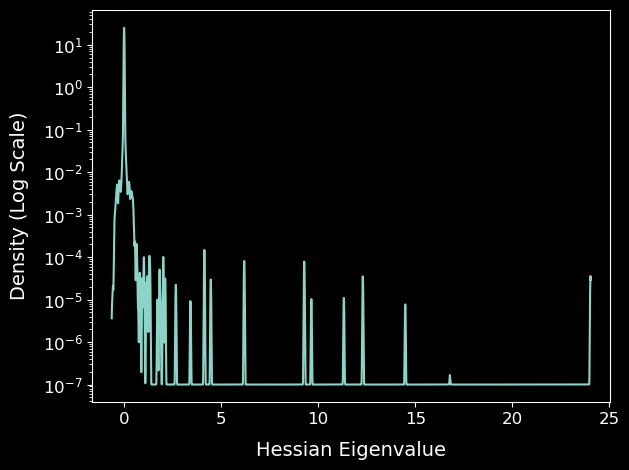

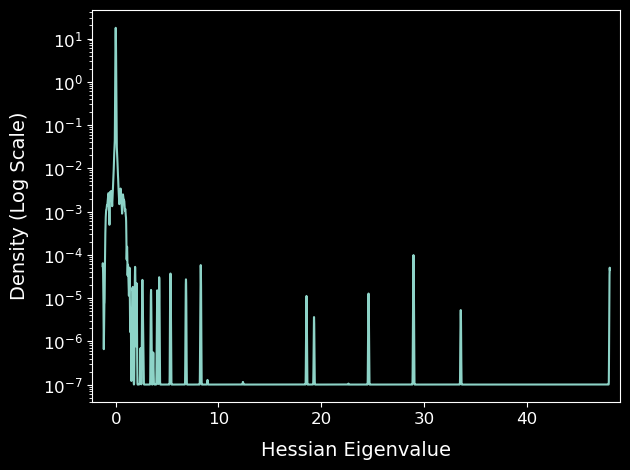

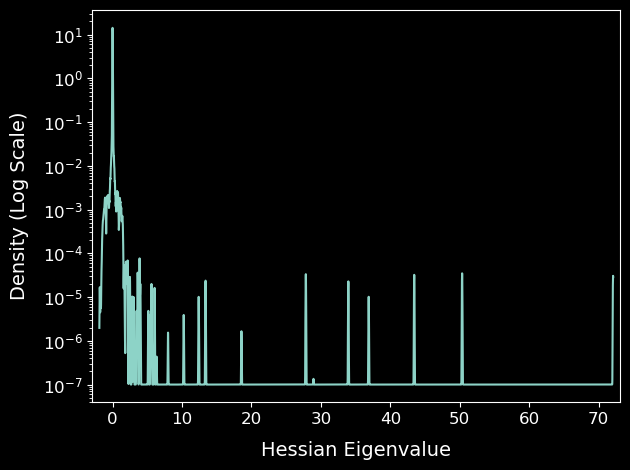

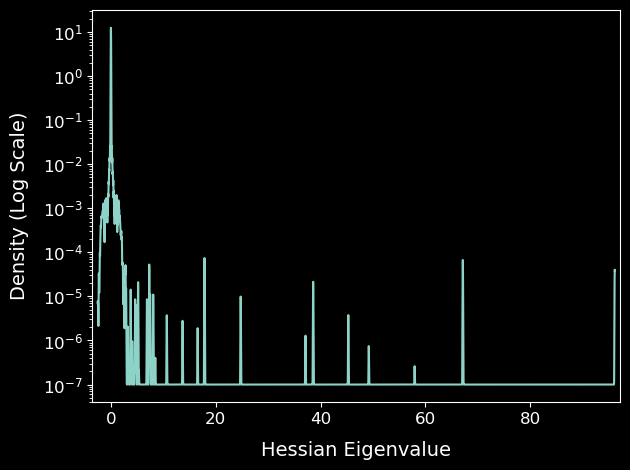

In [82]:
# Produce plots of eigenspectrums

for key, hess in hessians.items():
    density_eigen, density_weight = hess.density()
    get_esd_plot(density_eigen, density_weight)

In [ ]:
# STANDARD RLCT MEASUREMENT WITH FIXED HYPERPARAMETERS

rlct_estimates = {}
for optimizer in models:    
    print(f"======================== RLCT estimates for {optimizer} ==========================")
    for m in models[optimizer]:
        rlct_estimate = estimate_learning_coeff(
            m,
            train_loader,
            criterion=criterion["general"],
            optimizer_kwargs=dict(
                lr=hyperparams["lr"],
                noise_level=hyperparams["noise_level"],
                elasticity=hyperparams["elasticity"],
                num_samples=len(train_set),
                temperature="adaptive",
            ),
            sampling_method=SGLD,
            num_chains=hyperparams["num_chains"],
            num_draws=hyperparams["num_draws"],
            num_burnin_steps=0,
            num_steps_bw_draws=1,
            device=device,
        )
        if optimizer in rlct_estimates:
            rlct_estimates[optimizer].append(rlct_estimate)
        else:
            rlct_estimates[optimizer] = [rlct_estimate]
        print(f"RLCT estimate: {rlct_estimate}")
    average_rlct_estimate = np.sum(rlct_estimates[optimizer][-2:])/2        
    #wandb.log({"optimizer" : optimizer, "rlct_estimate" : average_rlct_estimate})
    print(f"======== FINAL RLCT ESTIMATE FOR {optimizer} : {average_rlct_estimate} ========")


In [20]:
# HYPERPARAMETER SWEEP FOR RLCT MEASUREMENTS

def wandb_rlct_estimation():
    """
    Used in hyperparameter sweep.
    Estimate RLCT for the first optimizer only using random hyperparameters for SGLD.
    """
    rlct_estimates = {}
    with wandb.init() as run:
        config = run.config
        for optimizer in ["Adam"]:    
            print(f"======================== RLCT estimates for {optimizer} ==========================")
            for m in models[optimizer]:
                rlct_estimate = estimate_learning_coeff(
                    m,
                    train_loader,
                    criterion=criterion["general"],
                    optimizer_kwargs=dict(
                        lr=hyperparams["lr"],
                        noise_level=config.noise_level,
                        elasticity=config.elasticity,
                        num_samples=len(train_set),
                        temperature="adaptive",
                    ),
                    sampling_method=SGLD,
                    num_chains=config.num_chains,
                    num_draws=config.num_draws,
                    num_burnin_steps=0,
                    num_steps_bw_draws=1,
                    device=device,
                )
                if optimizer in rlct_estimates:
                    rlct_estimates[optimizer].append(rlct_estimate)
                else:
                    rlct_estimates[optimizer] = [rlct_estimate]
            average_rlct_estimate = np.sum(rlct_estimates[optimizer][-5:])/5        
            wandb.log({"optimizer" : optimizer, "rlct_estimate" : average_rlct_estimate})
            print(f"###### FINAL RLCT ESTIMATE FOR {optimizer} : {average_rlct_estimate} ######")

In [ ]:
# RUN HYPERPARAMETER SWEEP

hyperparam_sweep_2 = wandb.sweep(sweep_config, project=PROJECT_NAME)
wandb.agent(hyperparam_sweep_2, wandb_rlct_estimation)

In [ ]:
# Save data as a bar plot to wandb

optimizer_rlct_vals = [[key, value[-1]] for key, value in rlct_estimates.items()]
table = wandb.Table(data=optimizer_rlct_vals, columns=["optimizer", "rlct"])
wandb.log({"rlct for optimizers" : wandb.plot.bar(table, "optimizer", "rlct", title="Final RLCT values for different optimizers")})

In [20]:
# Save RLCT estimates data to wandb

rlct_fig = go.Figure()

for optim, rlct_estimate in rlct_estimates.items():
    rlct_fig.add_trace(go.Scatter(x=epochs, y=rlct_estimate, mode='lines+markers', name=optim))

rlct_fig.update_layout(title="RLCT estimate",
                  xaxis_title="Epoch",
                  yaxis_title="RLCT",
                  legend_title="Optimizers",
                  )

wandb.log({"RLCT Estimates" : rlct_fig})

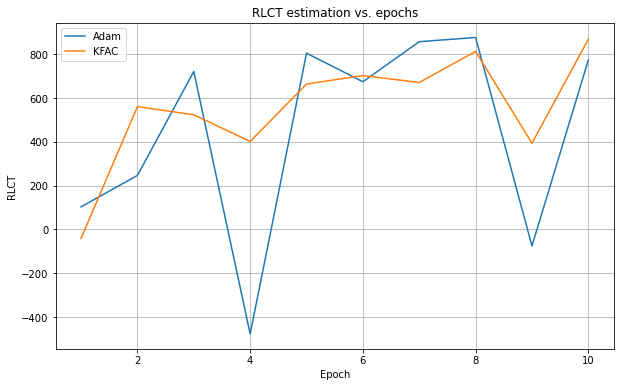

In [15]:
# Quick graphs to visualise how RLCT evolved over time

plt.figure(figsize=(10, 6))
for optim in rlct_estimates:
    data = {"Epochs" : np.arange(1, hyperparams["num_epochs"]+1), optim : rlct_estimates[optim]}
    plt.plot(np.arange(1, hyperparams["num_epochs"]+1), rlct_estimates[optim], label=optim)
plt.grid()
plt.title("RLCT estimation vs. epochs")
plt.xlabel("Epoch")
plt.ylabel("RLCT")
plt.legend()